In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [36]:
#Load Manufacturing 6G dataset
df_1 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Data\manufacturing_6G_dataset.csv")

In [37]:
# Count of null values
df_1.isna().sum()

Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64

In [38]:
len(df_1.columns)

13

In [39]:
# Select numerical features
features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score',
    'Error_Rate_%'
]

X = df_1[features]

In [40]:
len(X.columns)

9

In [41]:
# Step 1: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
# To visualise the change, converting Numpy array back to Dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,0.813716,0.672246,1.169291,-1.055549,-1.583668,0.951035,1.550706,-0.535763,1.720845
1,1.398308,0.569944,-1.418606,0.251843,-0.183580,-0.006809,0.939754,0.936468,0.040170
2,-0.909844,-0.332499,0.162437,-0.509772,-0.591715,-1.578551,-1.290132,1.688645,0.160127
3,-1.124100,-1.592313,-0.684589,0.254804,-0.923183,-0.147671,0.412488,1.675848,-1.098568
4,0.867184,-1.558672,0.195739,0.600082,1.595757,-0.943626,-0.897818,0.255293,1.060129


In [43]:
X.head()

,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470
1,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270
2,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391
3,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847
4,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686


In [44]:
# Let us play
# StandardScaler transform data with "Z" value i.e. (x-mu)/sigma
# I want to calculate z value without using class StandardScaler

In [46]:
list(X.columns)

['Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%']

In [59]:
# Approach 1
Temperature_C_mean = X['Temperature_C'].sum()/X['Temperature_C'].count() # count() ignores null values
Temperature_C_sv = np.sqrt(((X['Temperature_C'] - Temperature_C_mean)**2).sum()/(len(X['Temperature_C'])))

In [60]:
print(Temperature_C_sv)

17.323150930125344


In [70]:
# Approach 2
# I want to calculate standard deviation using for loop
a = []

for i in X['Temperature_C']:
    b = (i - Temperature_C_mean)**2/len(X['Temperature_C'])
    a.append(b)
variance = sum(a)
std_dev_C = np.sqrt(variance)

In [71]:
print(std_dev_C)

17.323150930125546


In [73]:
C_a = []
for i in X['Temperature_C']:
    b = (i - Temperature_C_mean)/std_dev_C
    C_a.append(b)

In [75]:
# Create a new comparison dataframe
comparison_df = pd.DataFrame({
    'Manual_Z_Score': C_a,
    'StandardScaler_Z_Score': X_scaled_df['Temperature_C']
})

# Display the first few rows to compare
print(comparison_df.head(20))

    Manual_Z_Score  StandardScaler_Z_Score
0         0.813716                0.813716
1         1.398308                1.398308
2        -0.909844               -0.909844
3        -1.124100               -1.124100
4         0.867184                0.867184
5         1.207536                1.207536
6         0.946320                0.946320
7        -1.291404               -1.291404
8         0.895054                0.895054
9        -0.214554               -0.214554
10        0.375743                0.375743
11       -0.340910               -0.340910
12       -1.687587               -1.687587
13        1.716432                1.716432
14       -1.125135               -1.125135
15        0.597791                0.597791
16       -0.966517               -0.966517
17       -1.605711               -1.605711
18        1.690675                1.690675
19       -1.711839               -1.711839


In [80]:
# Step 2: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [81]:
# Let us play again
# What fit does here - it does 03 things
# Calculates covariance matrix, Finds eigen vectors (It identifies the directions (Principal Components) where the data has the most "spread" or variance), 
# Calculates Eigen Values It determines how much information (variance) is trapped in each of those directions.
# Let us write code to calculate these 03 values from scratch
# Let us select  

[[ 1.00001000e+00  6.09739771e-04  4.58434751e-03 -2.46684940e-03
   2.86123842e-03 -2.23755819e-03  1.45078164e-03 -2.18783554e-03
  -1.80558281e-03]
 [ 6.09739771e-04  1.00001000e+00  5.34025214e-03  7.54656466e-03
   3.95937457e-04  3.57274155e-04 -1.33509561e-03  3.95718858e-03
   4.57935995e-03]
 [ 4.58434751e-03  5.34025214e-03  1.00001000e+00 -3.24465691e-03
  -1.19791106e-03 -9.17652349e-04  1.96963443e-03  1.62660973e-03
   8.89196947e-04]
 [-2.46684940e-03  7.54656466e-03 -3.24465691e-03  1.00001000e+00
  -6.88601606e-03 -4.35591196e-03 -1.04968323e-03 -2.90149164e-03
   9.80833988e-05]
 [ 2.86123842e-03  3.95937457e-04 -1.19791106e-03 -6.88601606e-03
   1.00001000e+00 -4.89745776e-03 -7.11901881e-03  7.55712574e-04
  -2.40612835e-03]
 [-2.23755819e-03  3.57274155e-04 -9.17652349e-04 -4.35591196e-03
  -4.89745776e-03  1.00001000e+00 -4.93701121e-03 -1.68186088e-04
  -1.48712821e-03]
 [ 1.45078164e-03 -1.33509561e-03  1.96963443e-03 -1.04968323e-03
  -7.11901881e-03 -4.9370112

In [87]:
list(X_scaled_df.columns)

['Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%']

In [94]:
X_scaled_sample = X_scaled_df[['Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%']]
X_scaled_sample.head()

,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,0.813716,0.672246,1.169291,-1.055549,-1.583668,0.951035,1.550706,-0.535763,1.720845
1,1.398308,0.569944,-1.418606,0.251843,-0.183580,-0.006809,0.939754,0.936468,0.040170
2,-0.909844,-0.332499,0.162437,-0.509772,-0.591715,-1.578551,-1.290132,1.688645,0.160127
3,-1.124100,-1.592313,-0.684589,0.254804,-0.923183,-0.147671,0.412488,1.675848,-1.098568
4,0.867184,-1.558672,0.195739,0.600082,1.595757,-0.943626,-0.897818,0.255293,1.060129


In [95]:
# 1. Convert your DataFrame to a NumPy array
X1 = X_scaled_sample.values

# 2. Subtract the mean of each column (Centering)
# axis=0 calculates mean per column
#X_meaned = X - np.mean(X, axis=0)

# 3. Calculate Covariance (Dot product divided by n-1)
# .T is the transpose needed for matrix multiplication
n = X.shape[0]
cov_matrix = (X1.T @ X1) / (n - 1)

print(cov_matrix)


[[ 1.00001000e+00  6.09739771e-04  4.58434751e-03 -2.46684940e-03
   2.86123842e-03 -2.23755819e-03  1.45078164e-03 -2.18783554e-03
  -1.80558281e-03]
 [ 6.09739771e-04  1.00001000e+00  5.34025214e-03  7.54656466e-03
   3.95937457e-04  3.57274155e-04 -1.33509561e-03  3.95718858e-03
   4.57935995e-03]
 [ 4.58434751e-03  5.34025214e-03  1.00001000e+00 -3.24465691e-03
  -1.19791106e-03 -9.17652349e-04  1.96963443e-03  1.62660973e-03
   8.89196947e-04]
 [-2.46684940e-03  7.54656466e-03 -3.24465691e-03  1.00001000e+00
  -6.88601606e-03 -4.35591196e-03 -1.04968323e-03 -2.90149164e-03
   9.80833988e-05]
 [ 2.86123842e-03  3.95937457e-04 -1.19791106e-03 -6.88601606e-03
   1.00001000e+00 -4.89745776e-03 -7.11901881e-03  7.55712574e-04
  -2.40612835e-03]
 [-2.23755819e-03  3.57274155e-04 -9.17652349e-04 -4.35591196e-03
  -4.89745776e-03  1.00001000e+00 -4.93701121e-03 -1.68186088e-04
  -1.48712821e-03]
 [ 1.45078164e-03 -1.33509561e-03  1.96963443e-03 -1.04968323e-03
  -7.11901881e-03 -4.9370112

In [98]:
# Calculate eigenvalues and eigenvectors from the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Print the results
print("Eigenvalues (Information captured by each axis):")
print(eigenvalues)

print("\nEigenvectors (The Principal Component directions):")
print(eigenvectors)

Eigenvalues (Information captured by each axis):
[0.98342604 0.98818593 1.01525453 0.9935451  0.99480562 1.01007304
 1.00316477 1.00677676 1.00485821]

Eigenvectors (The Principal Component directions):
[[-0.01192635  0.20182637 -0.07368155  0.60083736  0.31972339  0.43801532
  -0.36407538 -0.24289262 -0.32720208]
 [-0.3652204  -0.49243134  0.38803149  0.08751336  0.09136818 -0.0087394
  -0.03494392 -0.58663605  0.33482975]
 [ 0.24554364  0.1891819   0.21392051 -0.52438054 -0.30699219  0.42699437
  -0.49938265 -0.22212325  0.08883366]
 [ 0.55451979  0.19537867  0.2839274   0.15204918 -0.09051419 -0.53939675
   0.05781499 -0.44072863 -0.2321105 ]
 [ 0.50284053 -0.28205742 -0.37640536 -0.07805341  0.12991986  0.41521692
   0.48450128 -0.29001737  0.10810118]
 [ 0.40254831 -0.17877558 -0.15370881  0.20838382  0.23397267 -0.21259265
  -0.47943142  0.23629763  0.59440225]
 [ 0.27259863 -0.58800377  0.460624    0.10063212 -0.08037777  0.1762514
  -0.04846293  0.41125673 -0.38553127]
 [ 0.061

In [99]:
# Explained Variance Ratio to see what percentage of data's story is captured by principal components

# 1. Sort eigenvalues in descending order (highest variance first)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]

# 2. Calculate the ratio (Individual variance / Total variance)
# The sum of eigenvalues in scaled data equals the number of features
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# 3. Calculate cumulative variance (running total)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio (PC1 to PC9):")
print(explained_variance_ratio)

print("\nCumulative Explained Variance (How much of the total story is told):")
print(cumulative_variance)

Explained Variance Ratio (PC1 to PC9):
[0.11280493 0.11222922 0.11186297 0.1116498  0.11146164 0.11053285
 0.1103928  0.10979734 0.10926847]

Cumulative Explained Variance (How much of the total story is told):
[0.11280493 0.22503415 0.33689711 0.44854691 0.56000855 0.6705414
 0.78093419 0.89073153 1.        ]


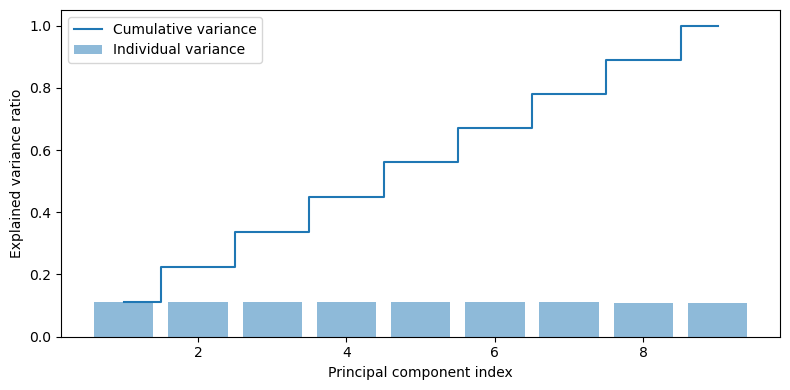

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(range(1, 10), explained_variance_ratio, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, 10), cumulative_variance, where='mid', label='Cumulative variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [101]:
# Now calculate PCA using inbuilt function
# Step number 3

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])


In [103]:
# Add label for interpretation
pca_df['Efficiency_Status'] = df_1['Efficiency_Status']


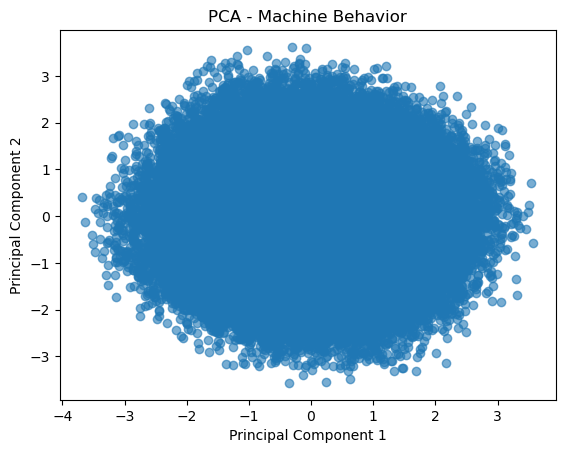

In [104]:
# Plot
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Machine Behavior")
plt.show()


In [105]:
## HOW MUCH INFORMATION DID WE RETAIN?
print(pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))


[0.11280493 0.11222922]
Total variance captured: 0.2250341466420921


In [106]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)

print(loadings)


     Temperature_C  Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  \
PC1      -0.073682      0.388031              0.213921            0.283927   
PC2      -0.438015      0.008739             -0.426994            0.539397   

     Packet_Loss_%  Quality_Control_Defect_Rate_%  \
PC1      -0.376405                      -0.153709   
PC2      -0.415217                       0.212593   

     Production_Speed_units_per_hr  Predictive_Maintenance_Score  Error_Rate_%  
PC1                       0.460624                      0.314921      0.490885  
PC2                      -0.176251                     -0.271838     -0.110597  
